**DYNAMIC SALES FORECASTING MODEL VIA XGBOOST REGRESSION**

Step 1: Generate synthetic sales data

Step 2: Feature engineering

Step 3: Time- Series split into training and testing sets

Step 4: Train via XGboost regression

Step 5: Evaluation of the forecast (MAE, WAPE)

Step 6: Plotting the forecast


In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

In [ ]:
#1. Generate 3 years of synthetic daily sales data
#1.1 Generate dates
dates = pd.date_range(start='2023-01-01', end='2025-12-31', freq='D')
np.random.seed(35) #ensure that dataset generated is same for each run

df = pd.DataFrame({'date': dates}) #convert into dataframe
df['day_of_week'] = df['date'].dt.dayofweek #add day of the week column to the dataframe

#1.2 Generate Sales data with trends and spikes
# Base Sales + upward trend + weekend spike + noise
trend = np.linspace(150,450,len(df)) #sales trend array starting with 150, ending with 250 with number of entries equal to entries in dates dataset
weekend_boost = np.where(df['day_of_week'] >= 4, 55, 0) #boost weekend sales
noise = np.random.normal(0,10,len(df)) #random number for each entry in dataset centered around 0 with standard deviation of 10

df['sales'] = np.maximum(0,trend + weekend_boost + noise) # ensure no neagative sales, add sales column to dataset
df = df.set_index('date')  # use date column as the new index for the data set


In [ ]:
#output of step 1
print(f"Dataset size: {df.shape}")
df.head(10)

Dataset size: (1096, 2)


,day_of_week,sales
date,,
2023-01-01,6,186.102633
2023-01-02,0,146.138051
2023-01-03,1,142.887685
2023-01-04,2,141.580651
2023-01-05,3,136.879912
2023-01-06,4,214.422423
2023-01-07,5,218.132453
2023-01-08,6,218.612092
2023-01-09,0,144.171688


In [ ]:
#2. Feature Engineering: calendar features, lag features, rolling window features

def create_dynamic_features(data):
  df = data.copy() # copy of original dataframe passed in the function

  #calendar features
  df['day_of_week'] = df.index.dayofweek
  df['month'] = df.index.month
  df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

  # Lag Features (What happened exactly X days ago?)
  #past values of a variable are strong predictors of its future values
  df['lag_1'] = df['sales'].shift(1)  # Yesterday
  df['lag_7'] = df['sales'].shift(7)  # Same day last week
  df['lag_30'] = df['sales'].shift(30) # Same day last month

  # Rolling Window Features (Momentum and Volatility)
  # Notice the .shift(1) - we only calculate rolling stats up until YESTERDAY
  df['rolling_7_mean'] = df['sales'].shift(1).rolling(window=7).mean()
  df['rolling_30_mean'] = df['sales'].shift(1).rolling(window=30).mean()
  df['rolling_7_std'] = df['sales'].shift(1).rolling(window=7).std() # Volatility

  # Drop rows with NaN values caused by shifting and rolling
  df = df.dropna()
  return df

df_features = create_dynamic_features(df)


Dataset size after feature engineering: (1066, 10)


In [ ]:
#output of step 2
print(f"Dataset size after feature engineering: {df_features.shape}")
df_features.head(5)

Dataset size after feature engineering: (1066, 10)


,day_of_week,sales,month,is_weekend,lag_1,lag_7,lag_30,rolling_7_mean,rolling_30_mean,rolling_7_std
date,,,,,,,,,,
2023-01-31,1,154.848725,1,0,141.972100,158.560156,186.102633,178.847144,176.672502,32.485827
2023-02-01,2,150.325201,2,0,154.848725,152.819138,146.138051,178.316939,175.630705,32.899768
2023-02-02,3,169.564048,2,0,150.325201,162.382448,142.887685,177.960662,175.770276,33.233716
2023-02-03,4,218.332713,2,0,169.564048,198.414247,141.580651,178.986605,176.659489,32.780415
2023-02-04,5,201.834436,2,1,218.332713,222.223694,136.879912,181.832100,179.217891,35.499621


In [ ]:
#3. Time- Series Split: Split the data into train and test. Last 90 days of data is hold out to later test the production performance

#3.1 Define target and features
TARGET = 'sales' #column of the dataset to be predicted
FEATURES = [col for col in df_features.columns if col != TARGET] #columns of the dataset as variables
# FEATURES = ['day_of_week', 'month', 'is_weekend', 'lag_1', 'lag_7', 'lag_30', 'rolling_7_mean', 'rolling_30_mean', 'rolling_7_std']

# Split: Train on everything except the last 90 days
train = df_features.iloc[:-90] #create df train from df_features, include all rows except last 90
test = df_features.iloc[-90:] #create df test from df_features, include only last 90 rows

X_train = train[FEATURES] #create df from train, include all columns from features list
y_train = train[TARGET] #create df from train, include only Target column

X_test = test[FEATURES]
y_test = test[TARGET]

print(f"Training days: {len(X_train)} | Testing days: {len(X_test)}")

Training days: 976 | Testing days: 90


In [ ]:
#4. XGBoost Regression

#Model Initialization
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    early_stopping_rounds=50,
    objective='reg:squarederror'
)

# Train the model, evaluating on the test set to stop early if it overfits
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100 # Print progress every 100 trees
)

[0]	validation_0-rmse:78.31161	validation_1-rmse:142.83483
[100]	validation_0-rmse:7.75533	validation_1-rmse:20.65426
[200]	validation_0-rmse:6.03814	validation_1-rmse:19.78106
[300]	validation_0-rmse:4.75396	validation_1-rmse:19.60527
[321]	validation_0-rmse:4.55813	validation_1-rmse:19.58515


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#5. Evaluating the forecast

# Predict on the test set
predictions = model.predict(X_test)
test_results = test.copy()
test_results['prediction'] = predictions

# Calculate Error
mae = mean_absolute_error(test_results['sales'], test_results['prediction'])
mean_sales = test_results['sales'].mean()
error_percentage = (mae / mean_sales) * 100

print(f"\n--- Model Performance ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} units")
print(f"Average Daily Sales in Test Set: {mean_sales:.2f} units")
print(f"Average Error Percentage (WAPE): {error_percentage:.2f}%")


--- Model Performance ---
Mean Absolute Error (MAE): 16.34 units
Average Daily Sales in Test Set: 461.26 units
Average Error Percentage (WAPE): 3.54%


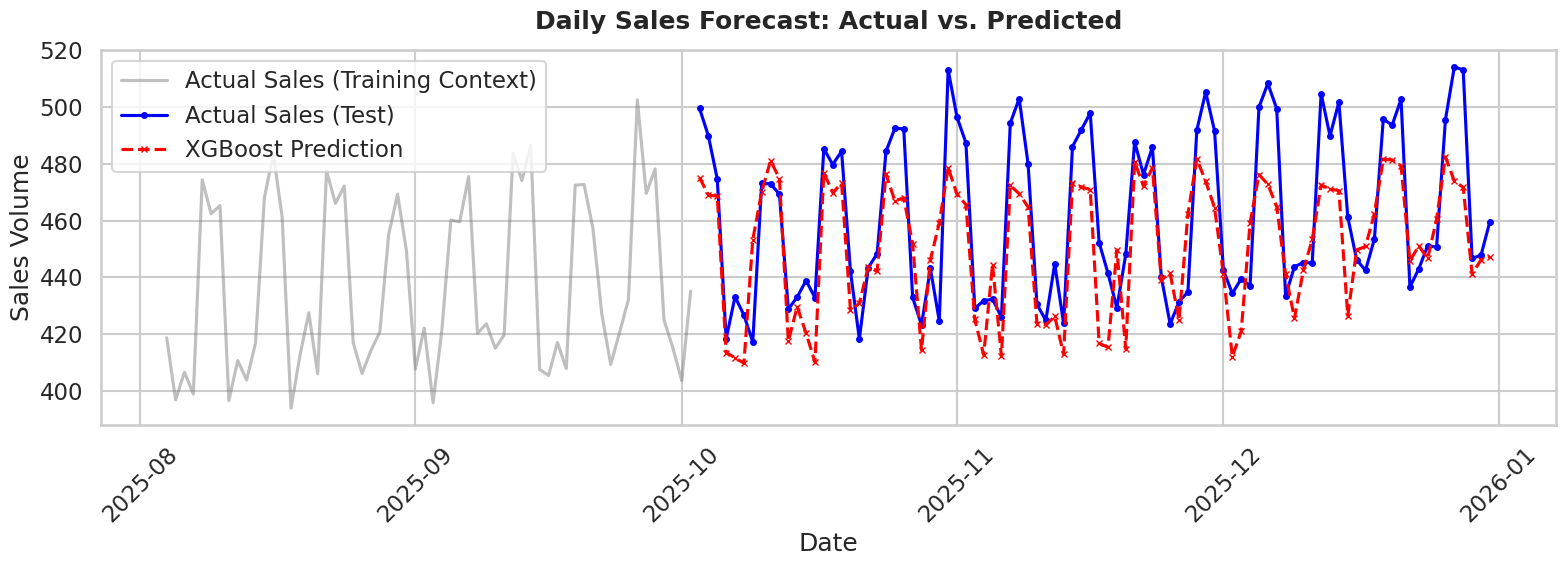

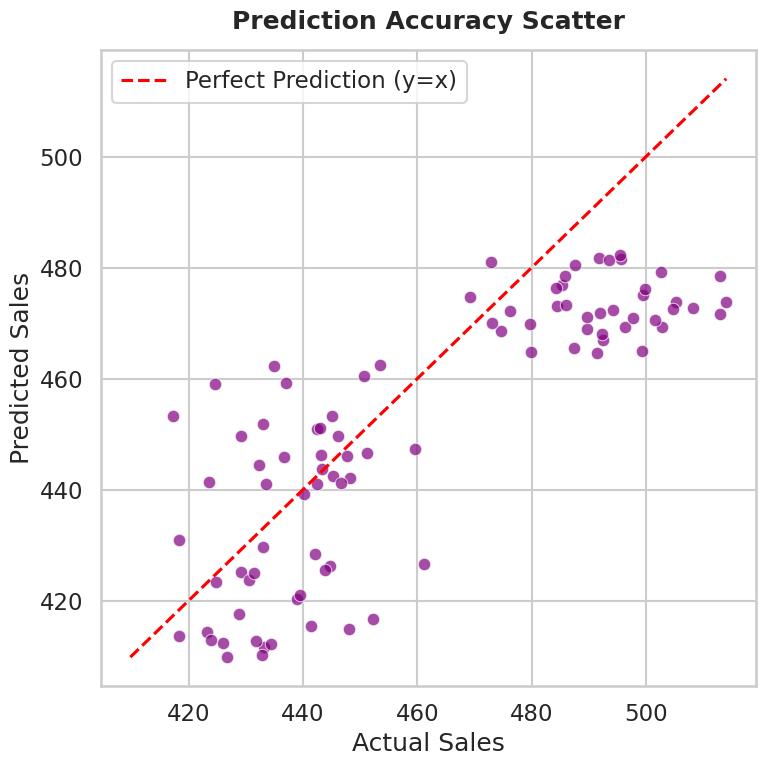

In [ ]:
#6. Plot the test, train and forecasts

import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid", context="talk")

# ==========================================
# Plot 1: Time Series (Actual vs Predicted)
# ==========================================
plt.figure(figsize=(16, 6))

# Plot the last 60 days of the training set to provide visual context
plt.plot(train.index[-60:], train['sales'][-60:],
         label='Actual Sales (Training Context)', color='gray', alpha=0.5)

# Plot the actual sales in the test set
plt.plot(test_results.index, test_results['sales'],
         label='Actual Sales (Test)', color='blue', marker='o', markersize=4)

# Plot the XGBoost predicted sales
plt.plot(test_results.index, test_results['prediction'],
         label='XGBoost Prediction', color='red', linestyle='--', marker='x', markersize=4)

# Formatting
plt.title('Daily Sales Forecast: Actual vs. Predicted', pad=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales Volume')
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==========================================
# Plot 2: Scatter Plot (Prediction Accuracy)
# ==========================================
plt.figure(figsize=(8, 8))

# Scatter actuals vs predictions
sns.scatterplot(x='sales', y='prediction', data=test_results,
                color='purple', alpha=0.7, s=80)

# Add the perfect prediction line (y=x)
min_val = min(test_results['sales'].min(), test_results['prediction'].min())
max_val = max(test_results['sales'].max(), test_results['prediction'].max())
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linestyle='--', label='Perfect Prediction (y=x)')

# Formatting
plt.title('Prediction Accuracy Scatter', pad=15, fontweight='bold')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.legend()
plt.tight_layout()
plt.show()